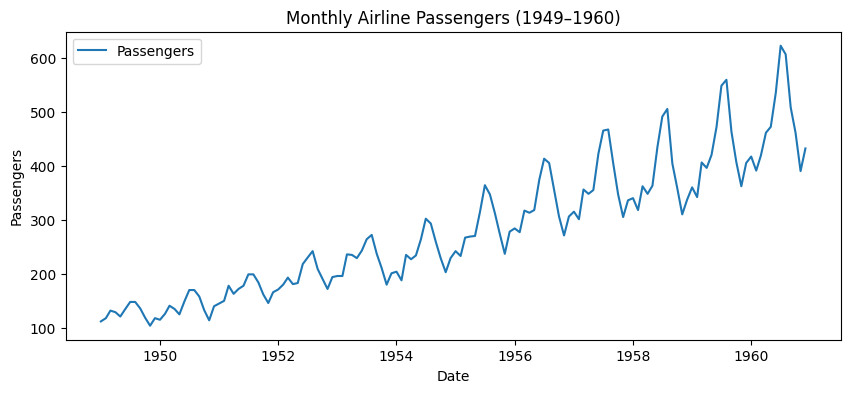

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")

# Plot raw data
plt.figure(figsize=(10,4))
plt.plot(df, label="Passengers")
plt.title("Monthly Airline Passengers (1949–1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Passengers"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641


p-value > 0.05 → non-stationary.

--> Apply differencing.

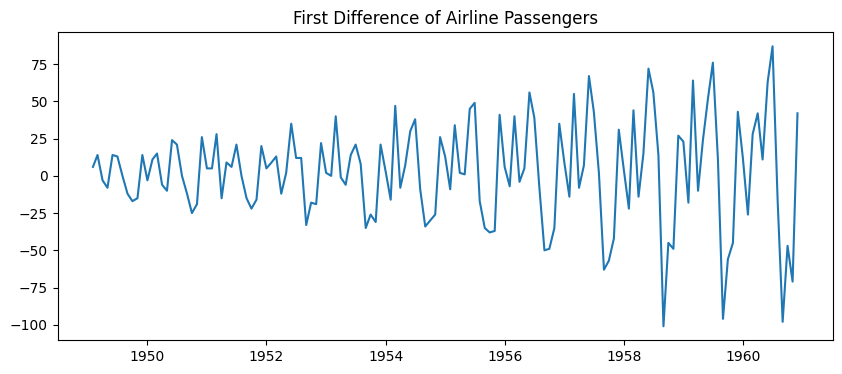

In [6]:
df_diff = df.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(df_diff, label="Differenced")
plt.title("First Difference of Airline Passengers")
plt.show()

AR view (levels persist)

MA view (surprises persist)

Inspect ACF and PACF

ACF shows correlation between 𝑦𝑡 and 𝑦𝑡−𝑘 at all lags (mixed effects of AR + MA).

PACF shows the direct correlation with 𝑦𝑡−𝑘, after removing influence of intermediate lags.	​

👉 In practice:

If PACF cuts off after lag 𝑝, it suggests an AR(p) structure.

If ACF cuts off after lag 𝑞, it suggests an MA(q) structure.

👉 Rule of thumb:

- Use AR when plots of the autocorrelation function (ACF) decay gradually.

- Use MA when ACF cuts off sharply after a few lags but partial autocorrelation (PACF) decays.

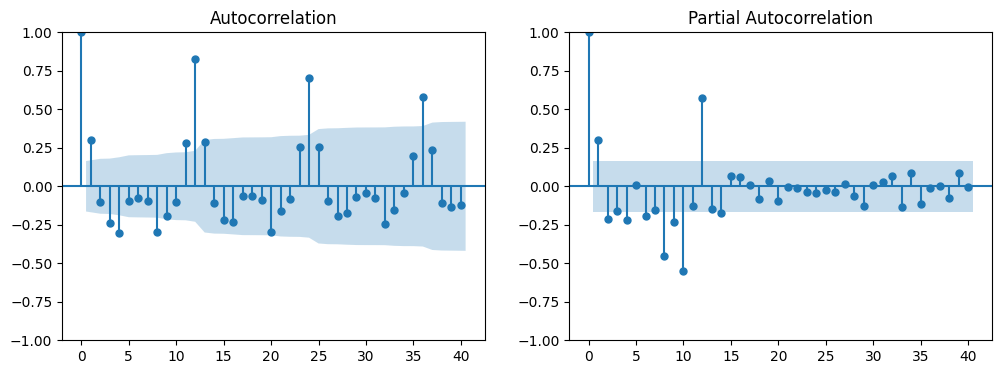

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(df_diff, ax=ax[0], lags=40)
plot_pacf(df_diff, ax=ax[1], lags=40)
plt.show()

ACF shows slow decay → suggests AR terms.

PACF shows cutoff after lag 1 → suggests AR(1).

We might try ARIMA(1,1,1).

Fit ARIMA(p,d,q)

In [26]:
import statsmodels.api as sm
# Fit ARIMA(p,d,q)
# Parameters: p, d, q
# p = #lags (AR)
# d = #differencing steps (to remove trend)
# q = #lags of errors (MA)

model = sm.tsa.ARIMA(df["Passengers"], order=(12,1,1))
results = model.fit()
print(results.summary())

C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                ARIMA(12, 1, 1)   Log Likelihood                -558.720
Date:                Tue, 02 Sep 2025   AIC                           1145.441
Time:                        11:36:59   BIC                           1186.921
Sample:                    01-01-1949   HQIC                          1162.296
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1042      0.066      1.574      0.115      -0.026       0.234
ar.L2         -0.0910      0.060     -1.520      0.129      -0.208       0.026
ar.L3          0.0099      0.054      0.184      0.8

C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Parameters look significant.

Model captures trend + short-term corrections.

5. Diagnose Residuals

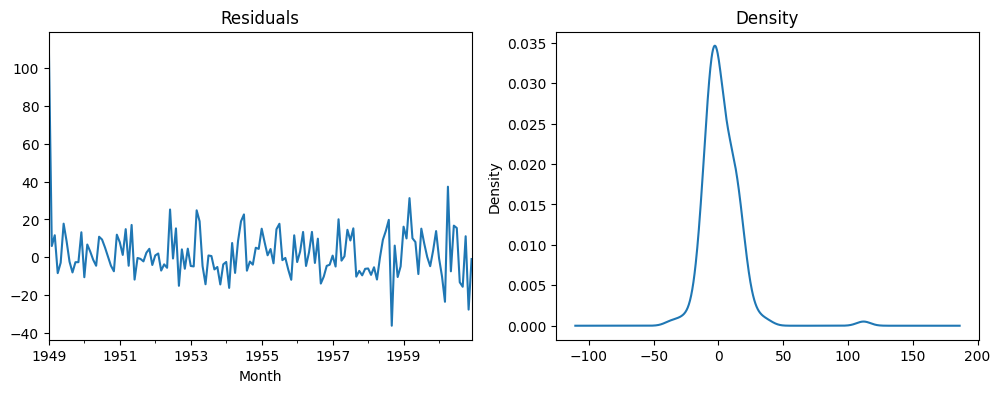

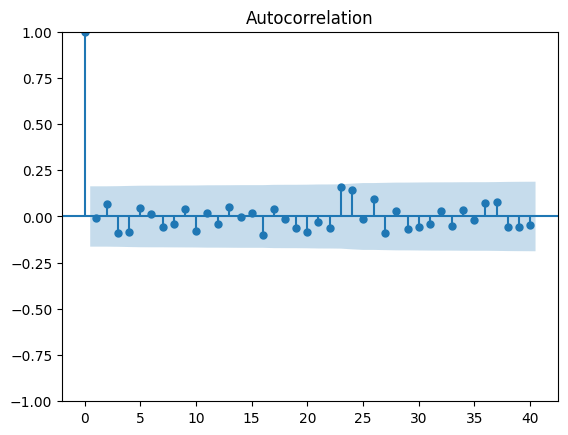

In [27]:
residuals = results.resid

fig, ax = plt.subplots(1,2, figsize=(12,4))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind="kde", title="Density", ax=ax[1])
plt.show()

plot_acf(residuals, lags=40)
plt.show()

Residuals look like white noise.

No strong autocorrelation left → good fit.

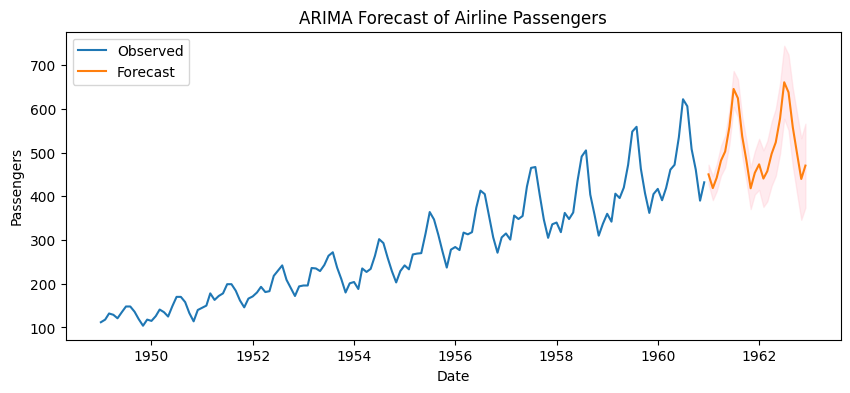

In [28]:
forecast = results.get_forecast(steps=24)  # 2 years ahead
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10,4))
plt.plot(df, label="Observed")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1], color="pink", alpha=0.3)
plt.title("ARIMA Forecast of Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()


Forecast continues upward trend.

Seasonal pattern is weaker (ARIMA doesn’t explicitly model seasonality; SARIMA would).

Confidence intervals widen over time → reflecting growing uncertainty.